# Multiple Linear Regression in PySpark

In [1]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import matplotlib.pyplot as plt


## 1. Create Spark session

In [2]:
spark = SparkSession.builder     .appName("MultipleLinearRegression")     .getOrCreate()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/05/12 00:52:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
spark

## 2. Generate synthetic data for multiple regression

In [5]:
import numpy as np
import pandas as pd

In [7]:
np.random.seed(42)
n = 100
X1 = np.random.rand(n)
X2 = np.random.rand(n)
y = 4 + 3*X1 + 5*X2 + np.random.randn(n)

In [8]:
df_pd = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

In [12]:
df_spark = spark.createDataFrame(df_pd.to_dict(orient='records'))

In [13]:
df_spark.show(5)

+-------------------+-------------------+------------------+
|                 X1|                 X2|                 y|
+-------------------+-------------------+------------------+
| 0.3745401188473625|0.03142918568673425| 4.600741563397268|
| 0.9507143064099162| 0.6364104112637804|10.266448672709654|
| 0.7319939418114051| 0.3143559810763267|  8.06083420411453|
| 0.5986584841970366| 0.5085706911647028| 7.624477490388255|
|0.15601864044243652|  0.907566473926093| 10.87166280210253|
+-------------------+-------------------+------------------+
only showing top 5 rows



## 3. Assemble features into a single vector column

In [14]:
assembler = VectorAssembler(inputCols=["X1", "X2"], outputCol="features")
assembled = assembler.transform(df_spark)


## 4. Fit the linear regression model

In [15]:
lr = LinearRegression(featuresCol="features", labelCol="y")
model = lr.fit(assembled)

# Coefficients and intercept
print("Coefficients:", model.coefficients)
print("Intercept:", model.intercept)


25/05/12 00:59:54 WARN Instrumentation: [03969715] regParam is zero, which might cause numerical instability and overfitting.


25/05/12 01:00:17 WARN InstanceBuilder$NativeBLAS: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/05/12 01:00:17 WARN InstanceBuilder$NativeBLAS: Failed to load implementation from:dev.ludovic.netlib.blas.ForeignLinkerBLAS


25/05/12 01:00:31 WARN InstanceBuilder$NativeLAPACK: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Coefficients: [2.658274678972615,5.71931141010068]
Intercept: 3.9106100364500698


## 5. Evaluate model performance

In [16]:
training_summary = model.summary
print("RMSE:", training_summary.rootMeanSquaredError)
print("R^2:", training_summary.r2)


RMSE: 0.9724565862804095
R^2: 0.7778893041851406


## 6. Plot predicted vs actual values

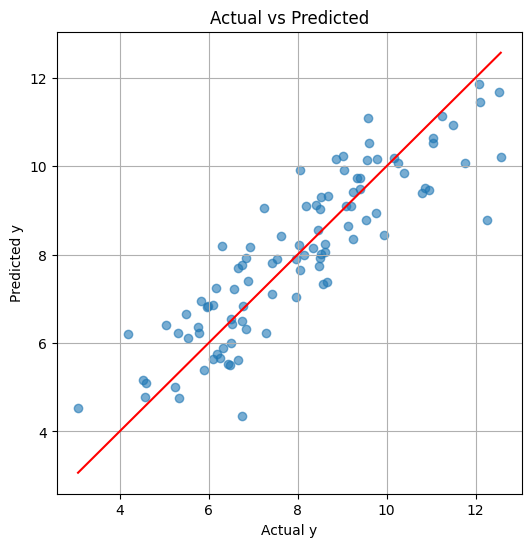

In [17]:
predictions = model.transform(assembled).select("y", "prediction")
pdf = predictions.toPandas()

plt.figure(figsize=(6, 6))
plt.scatter(pdf["y"], pdf["prediction"], alpha=0.6)
plt.plot([pdf["y"].min(), pdf["y"].max()], [pdf["y"].min(), pdf["y"].max()], color='red')
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()
